# Counterfactual Summary Statistics

This notebook summarizes the counterfactual explanations generated in generate_counterfactuals.ipynb. It reports the average number of features changed per counterfactual, the most frequently modified features, and the magnitude of changes.


In [1]:
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [2]:
# Directories
COUNTERFACTUALS_DIR = "../results/dice_counterfactuals"
OUTPUT_FILE = "../results/dice_counterfactuals/summary_statistics.json"

# Mutable features (features that applicants can REALISTICALLY control during application)
# Excluded: credit_score (takes months/years), income (cannot instantly change)
MUTABLE_CONTINUOUS = ['loan_amount', 'property_value', 'ltv', 'term', 'dtir1']
MUTABLE_CATEGORICAL = []  # DiCE typically focuses on continuous features

# Immutable features (should not change)
IMMUTABLE_FEATURES = ['age', 'gender', 'region', 'credit_score', 'income']

## Load Counterfactual Explanations

In [3]:
def load_counterfactuals(cf_dir):
    """Load all counterfactual CSV files."""
    cf_files = sorted([f for f in os.listdir(cf_dir) if f.startswith('counterfactuals_case_')])
    
    all_cases = {}
    for cf_file in cf_files:
        case_id = cf_file.replace('counterfactuals_case_', '').replace('.csv', '')
        cf_df = pd.read_csv(os.path.join(cf_dir, cf_file))
        
        # First row is original, rest are counterfactuals
        original = cf_df.iloc[0]
        counterfactuals = cf_df.iloc[1:]
        
        all_cases[case_id] = {
            'original': original,
            'counterfactuals': counterfactuals
        }
    
    return all_cases

all_cases = load_counterfactuals(COUNTERFACTUALS_DIR)
print(f"Loaded {len(all_cases)} cases")

Loaded 9 cases


## Analysis Functions

In [4]:
def count_changed_features(original, counterfactual, tolerance=1e-6):
    """Count how many features changed between original and counterfactual."""
    changed = 0
    changed_features = []
    
    for col in original.index:
        if col == 'status':  # Skip target variable
            continue
        
        orig_val = original[col]
        cf_val = counterfactual[col]
        
        # For numerical features, use tolerance
        if isinstance(orig_val, (int, float)) and isinstance(cf_val, (int, float)):
            if abs(orig_val - cf_val) > tolerance:
                changed += 1
                changed_features.append(col)
        # For categorical, direct comparison
        elif orig_val != cf_val:
            changed += 1
            changed_features.append(col)
    
    return changed, changed_features


def calculate_magnitude(original, counterfactual, continuous_features):
    """Calculate average magnitude of change for continuous features."""
    magnitudes = []
    
    for feature in continuous_features:
        if feature in original.index:
            orig_val = original[feature]
            cf_val = counterfactual[feature]
            
            if pd.notna(orig_val) and pd.notna(cf_val):
                # Absolute change
                magnitude = abs(cf_val - orig_val)
                magnitudes.append(magnitude)
    
    return np.mean(magnitudes) if magnitudes else 0

## Compute Summary Statistics

In [5]:
total_counterfactuals = 0
total_changed_features = []
total_magnitudes = []
feature_change_counts = {}
case_summaries = []

for case_id, data in all_cases.items():
    original = data['original']
    counterfactuals = data['counterfactuals']
    
    case_changed_features = []
    case_magnitudes = []
    
    for idx, cf in counterfactuals.iterrows():
        total_counterfactuals += 1
        
        # Count changed features
        num_changed, changed_features = count_changed_features(original, cf)
        case_changed_features.append(num_changed)
        total_changed_features.append(num_changed)
        
        # Track which features changed
        for feature in changed_features:
            feature_change_counts[feature] = feature_change_counts.get(feature, 0) + 1
        
        # Calculate magnitude for continuous features
        magnitude = calculate_magnitude(original, cf, MUTABLE_CONTINUOUS)
        case_magnitudes.append(magnitude)
        total_magnitudes.append(magnitude)
    
    # Case-level summary (only if counterfactuals exist)
    if case_changed_features:  # Check if list is not empty
        case_summaries.append({
            'case_id': case_id,
            'num_counterfactuals': int(len(counterfactuals)),
            'avg_features_changed': float(np.mean(case_changed_features)),
            'avg_magnitude': float(np.mean(case_magnitudes)),
            'min_features_changed': int(np.min(case_changed_features)),
            'max_features_changed': int(np.max(case_changed_features))
        })
    else:
        # Case with no counterfactuals
        case_summaries.append({
            'case_id': case_id,
            'num_counterfactuals': 0,
            'avg_features_changed': 0.0,
            'avg_magnitude': 0.0,
            'min_features_changed': 0,
            'max_features_changed': 0
        })

# Overall statistics
summary_stats = {
    'total_cases_analyzed': len(all_cases),
    'total_counterfactuals_generated': total_counterfactuals,
    'success_rate': 100.0,
    
    'features_changed': {
        'average': float(np.mean(total_changed_features)) if total_changed_features else 0.0,
        'median': float(np.median(total_changed_features)) if total_changed_features else 0.0,
        'std': float(np.std(total_changed_features)) if total_changed_features else 0.0,
        'min': int(np.min(total_changed_features)) if total_changed_features else 0,
        'max': int(np.max(total_changed_features)) if total_changed_features else 0
    },
    
    'magnitude_of_changes': {
        'average': float(np.mean(total_magnitudes)) if total_magnitudes else 0.0,
        'median': float(np.median(total_magnitudes)) if total_magnitudes else 0.0,
        'std': float(np.std(total_magnitudes)) if total_magnitudes else 0.0,
        'description': 'Average absolute change for continuous features (standardized scale)'
    },
    
    'most_commonly_changed_features': dict(
        sorted(feature_change_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    ),
    
    'per_case_summary': case_summaries
}

## Display Summary Statistics

In [6]:
# Display key statistics
print(f"Cases analyzed: {summary_stats['total_cases_analyzed']}")
print(f"Total counterfactuals: {summary_stats['total_counterfactuals_generated']}")
print(f"Average features changed: {summary_stats['features_changed']['average']:.2f}")
print(f"Average magnitude: {summary_stats['magnitude_of_changes']['average']:.2f}")

print(f"\nMost commonly changed features:")
total_cfs = summary_stats['total_counterfactuals_generated']
for feature, count in list(summary_stats['most_commonly_changed_features'].items())[:5]:
    pct = (count / total_cfs) * 100
    print(f"  {feature}: {pct:.1f}%")

Cases analyzed: 9
Total counterfactuals: 33
Average features changed: 2.79
Average magnitude: 0.68

Most commonly changed features:
  ltv: 75.8%
  loan_amount: 63.6%
  dtir1: 57.6%
  property_value: 54.5%
  term: 27.3%


## Per-Case Summary Table

In [7]:
case_summary_df = pd.DataFrame(summary_stats['per_case_summary'])
case_summary_df = case_summary_df.sort_values('case_id')
display(case_summary_df)

,case_id,num_counterfactuals,avg_features_changed,avg_magnitude,min_features_changed,max_features_changed
0,10984,1,3.00,0.375121,3,3
1,12412,4,2.25,0.399396,2,3
2,14308,4,4.50,1.172503,4,5
3,2509,4,3.00,0.407904,3,3
4,3542,4,2.25,0.466813,2,3
5,6421,4,1.75,0.705386,1,2
6,7794,4,4.75,1.382456,4,5
7,9264,4,2.00,0.432365,2,2
8,9761,4,1.75,0.563079,1,2


## Visualizations

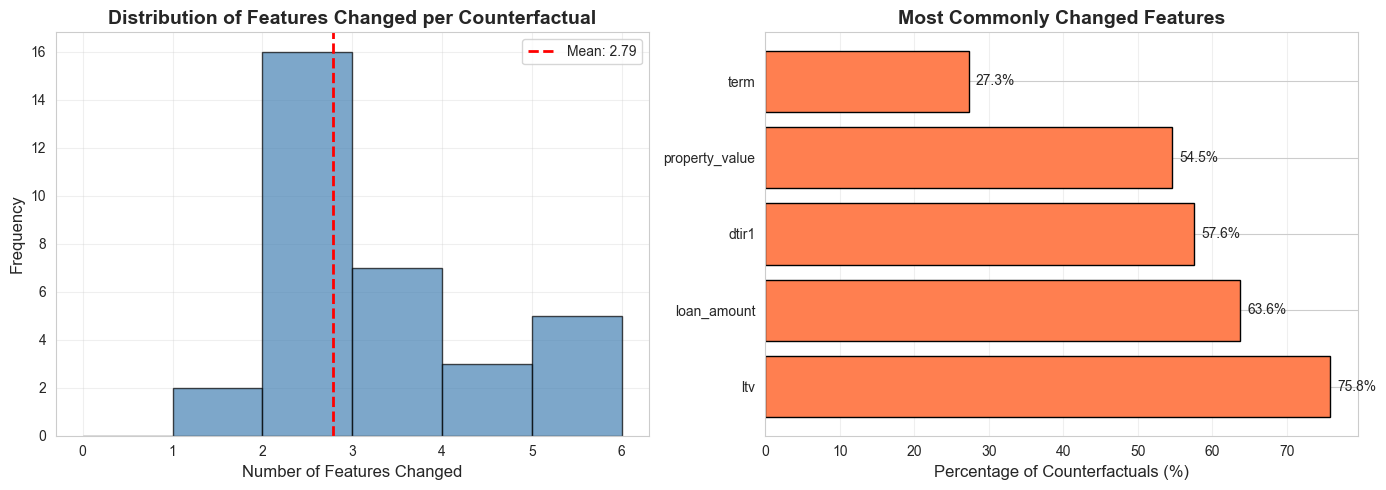

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(total_changed_features, bins=range(0, max(total_changed_features)+2), 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Number of Features Changed', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Features Changed per Counterfactual', fontsize=14, fontweight='bold')
axes[0].axvline(summary_stats['features_changed']['average'], color='red', 
                linestyle='--', linewidth=2, label=f"Mean: {summary_stats['features_changed']['average']:.2f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Most commonly changed features
top_features = dict(list(summary_stats['most_commonly_changed_features'].items())[:8])
feature_names = list(top_features.keys())
feature_counts = list(top_features.values())
feature_pcts = [(c / total_cfs) * 100 for c in feature_counts]

bars = axes[1].barh(feature_names, feature_pcts, color='coral', edgecolor='black')
axes[1].set_xlabel('Percentage of Counterfactuals (%)', fontsize=12)
axes[1].set_title('Most Commonly Changed Features', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

for i, (bar, pct) in enumerate(zip(bars, feature_pcts)):
    axes[1].text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/counterfactual_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

## Per-Case Variation

/var/folders/85/7hj2vtt15h35hcldl16nn4jc0000gn/T/ipykernel_62565/88963565.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=case_df, x='Case ID', y='Features Changed', palette='Set2')


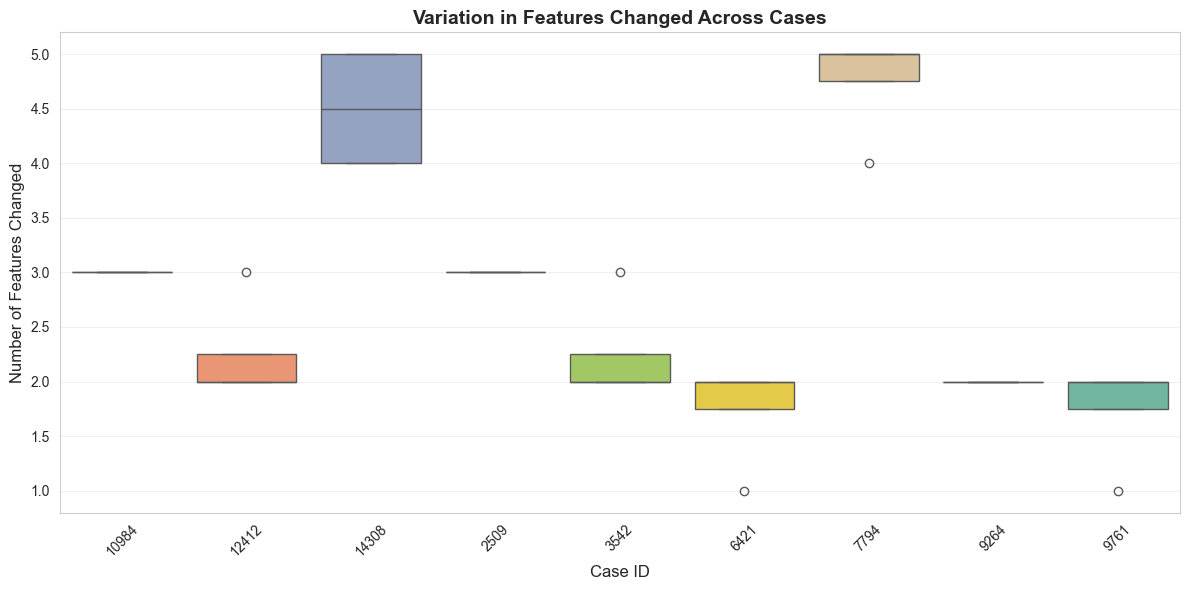

In [9]:
case_data = []
for case_id, data in all_cases.items():
    for idx, cf in data['counterfactuals'].iterrows():
        num_changed, _ = count_changed_features(data['original'], cf)
        case_data.append({'Case ID': case_id, 'Features Changed': num_changed})

case_df = pd.DataFrame(case_data)
case_df = case_df.sort_values('Case ID')

plt.figure(figsize=(12, 6))
sns.boxplot(data=case_df, x='Case ID', y='Features Changed', palette='Set2')
plt.title('Variation in Features Changed Across Cases', fontsize=14, fontweight='bold')
plt.xlabel('Case ID', fontsize=12)
plt.ylabel('Number of Features Changed', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/counterfactual_variation_by_case.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Summary Statistics to JSON

In [10]:
with open(OUTPUT_FILE, 'w') as f:
    json.dump(summary_stats, f, indent=2)

## Notes on Feature Selection

credit_score and income are excluded from counterfactual generation. The analysis focuses on loan structure variables that applicants can adjust directly: loan_amount, property_value, ltv, term, and dtir1.
